In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Farooq_Hussain\Python\Data Analysis\05 - EDA_Zomato\data\zomato.csv", encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [17]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")
df.info()
df.describe()

Dataset contains 9551 rows and 21 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [19]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [21]:
# Dropping unnecessary columns

df = df.drop(['Switch to order menu'], axis=1)
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

Dataset contains 9551 rows and 20 columns


In [23]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [25]:
# Checking duplicate values

df.duplicated().sum()

0

In [29]:
def save_plot(name):
    plt.savefig(fr"D:\Farooq_Hussain\Python\Data Analysis\05 - EDA_Zomato\images/{name}.png", dpi=300, bbox_inches="tight")

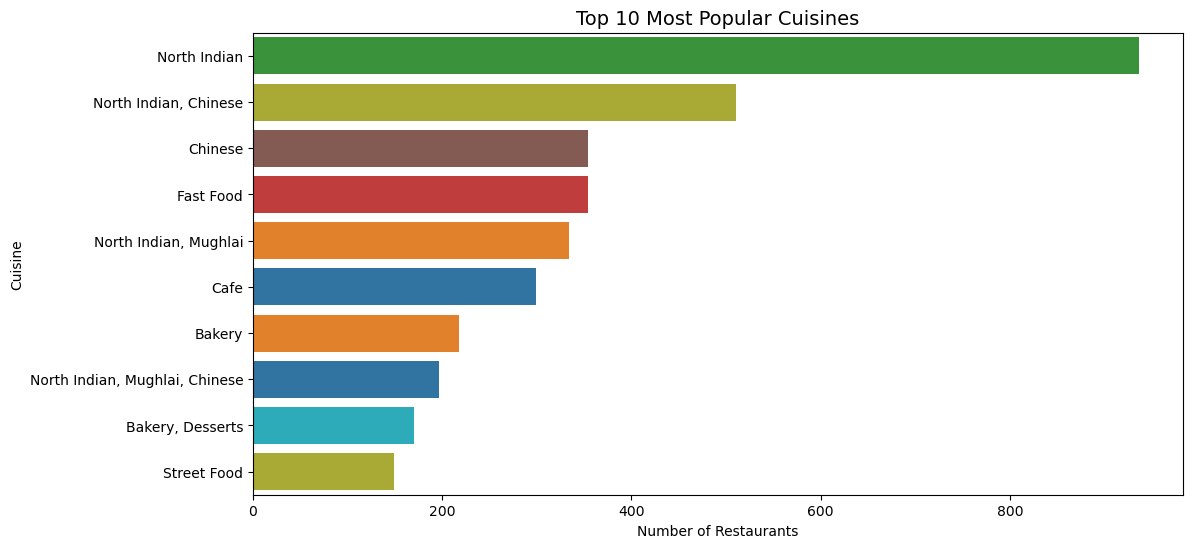

In [31]:
# Q1. Which cuisines are most popular?

plt.figure(figsize=(12,6))
sns.countplot(
    y='Cuisines',
    data=df,
    order=df['Cuisines'].value_counts().index[:10],
    hue='Cuisines',
    legend=False,
    palette="tab10"
)
plt.title("Top 10 Most Popular Cuisines", fontsize=14)
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
save_plot('Top_10_Most_Popular_Cuisines')
plt.show()

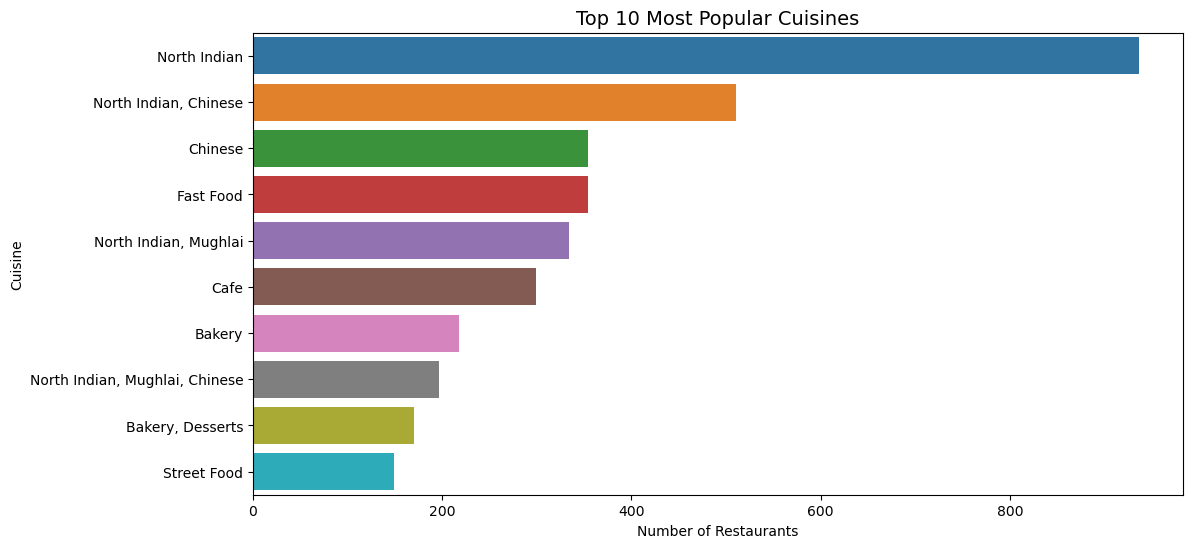

In [33]:
# Q1. Which cuisines are most popular?

top_cuisines = df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index,
    hue=top_cuisines.index,
    legend=False,
    palette="tab10"
)
plt.title("Top 10 Most Popular Cuisines", fontsize=14)
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()

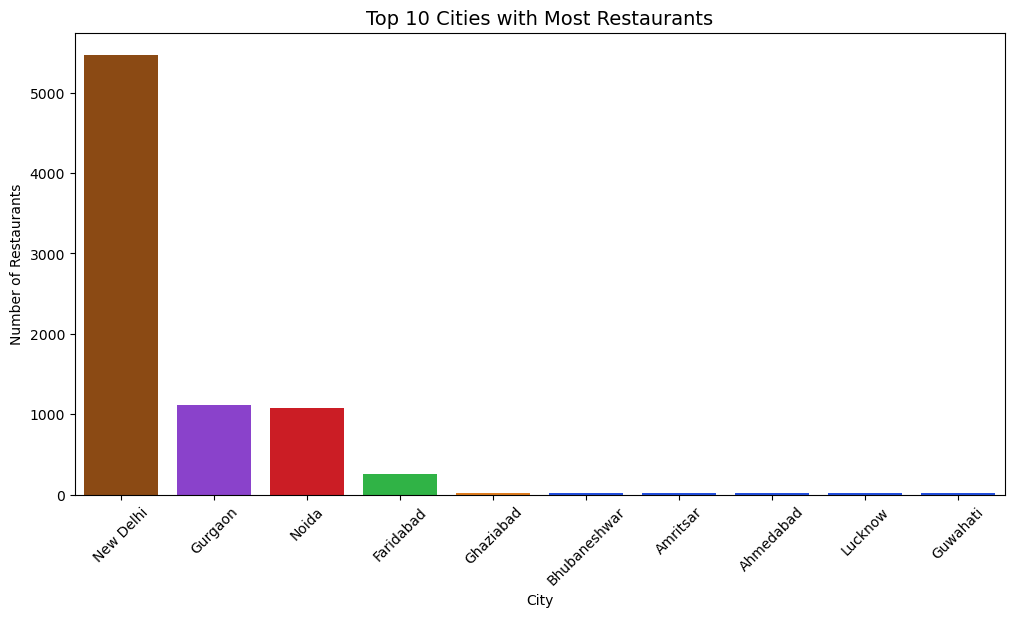

In [35]:
# Q2. Which cities have the most restaurants?

top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.values,
    legend=False,
    palette="bright"
)
plt.title("Top 10 Cities with Most Restaurants", fontsize=14)
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
save_plot('Top_10_Cities_with_Most_Restaurants')
plt.show()

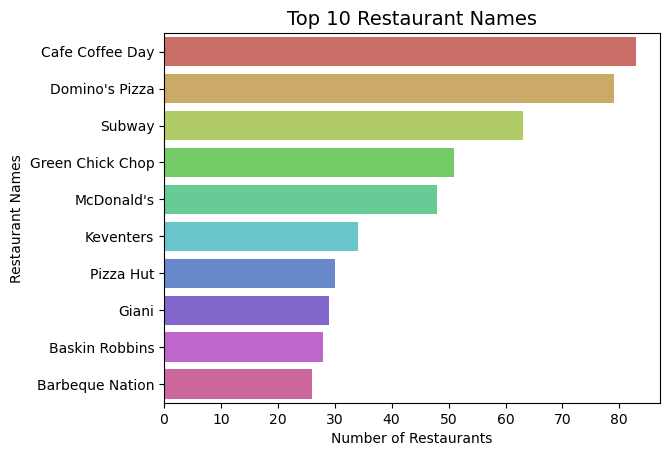

In [37]:
# Q3. Which restaurant dominate the market?

top_restaurants = df['Restaurant Name'].value_counts().head(10)

sns.barplot(
    x=top_restaurants.values,
    y=top_restaurants.index,
    hue=top_restaurants.index,
    legend=False,
    palette="hls"
)
plt.title("Top 10 Restaurant Names", fontsize=14)
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Names")
save_plot('Top_10_Restaurant_Names')
plt.show()

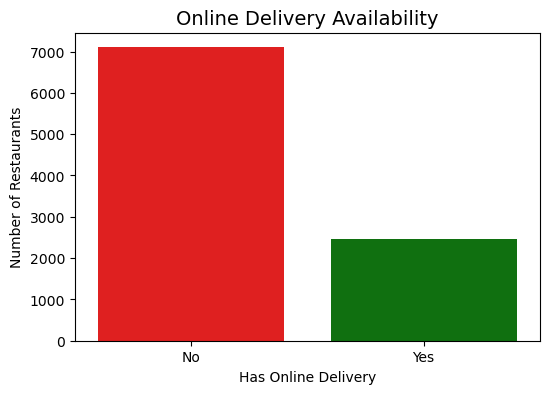

In [39]:
# Q4. Online delivery availability

plt.figure(figsize=(6,4))
sns.countplot(
    x='Has Online delivery',
    hue='Has Online delivery',
    data=df,
    legend=False,
    palette={"Yes": "green", "No": "red"}
)
plt.title('Online Delivery Availability', fontsize=14)
plt.xlabel("Has Online Delivery")
plt.ylabel("Number of Restaurants")
save_plot('Online_Delivery_Availability')
plt.show()

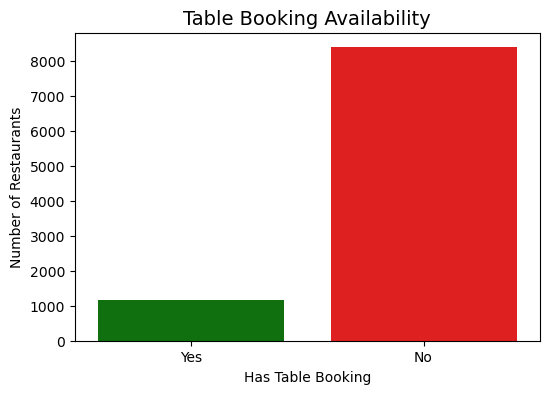

In [41]:
# Q5. Table booking availability

plt.figure(figsize=(6,4))
sns.countplot(
    x='Has Table booking',
    hue='Has Table booking',
    data=df,
    legend=False,
    palette={"Yes": "green", "No": "red"}
)
plt.title('Table Booking Availability', fontsize=14)
plt.xlabel("Has Table Booking")
plt.ylabel("Number of Restaurants")
save_plot('Table_Booking_Availability')
plt.show()

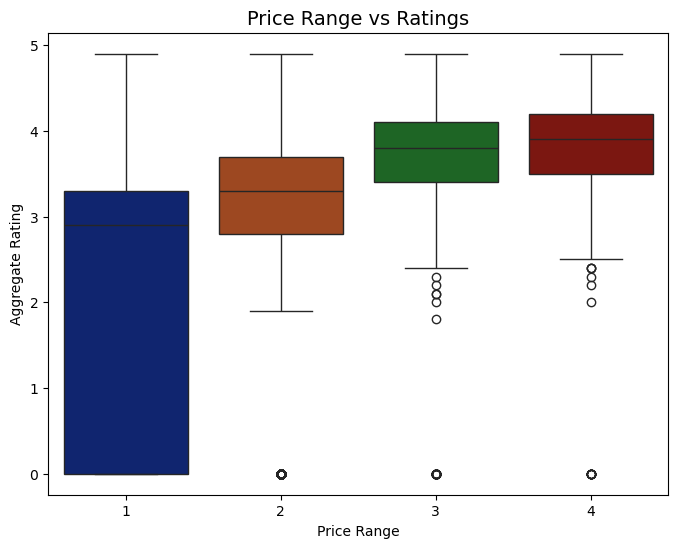

In [43]:
# Q6. Relationship between price range and rating

plt.figure(figsize=(8,6))
sns.boxplot(
    x='Price range',
    y='Aggregate rating',
    data=df, hue='Price range',
    palette='dark',
    legend=False
)
plt.title('Price Range vs Ratings', fontsize=14)
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
save_plot('Price_Range_vs_Ratings')
plt.show()

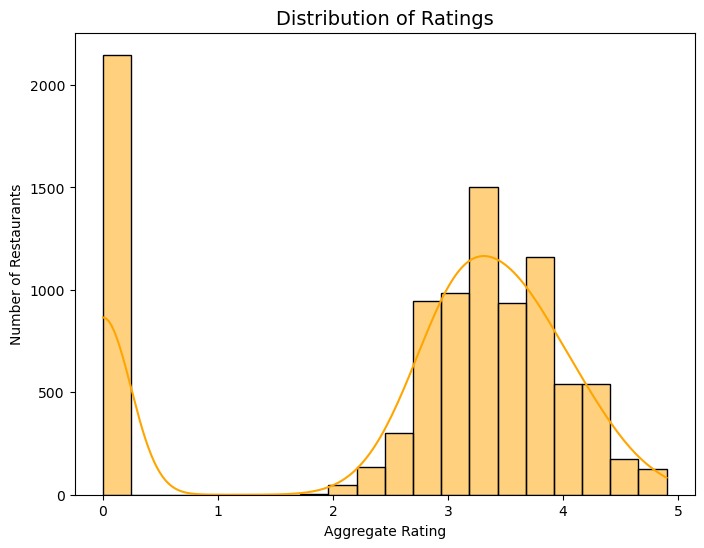

In [45]:
# Q7. Ratings distribution

plt.figure(figsize=(8,6))

#     hue='Aggregate rating',
#     palette="viridis"
# )
sns.histplot(
    data=df,
    x='Aggregate rating',
    bins=20,
    kde=True,
    color="Orange"
)

plt.title('Distribution of Ratings', fontsize=14)
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
save_plot('Distribution_of_Ratings')
plt.show()

In [ ]:
Final Summary of Insights:

1. Popular cuisines include North Indian, Chinese and Fast Food.
2. The majority of restaurants are concentrated in a few cities and countries.
3. Cafe Coffee Day and Dominos Pizza dominate the market.
4. Online delivery and table booking options vary widely.
5. Price range does not have a strong correlation with higher ratings.